<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/Severe_Housing_Problems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

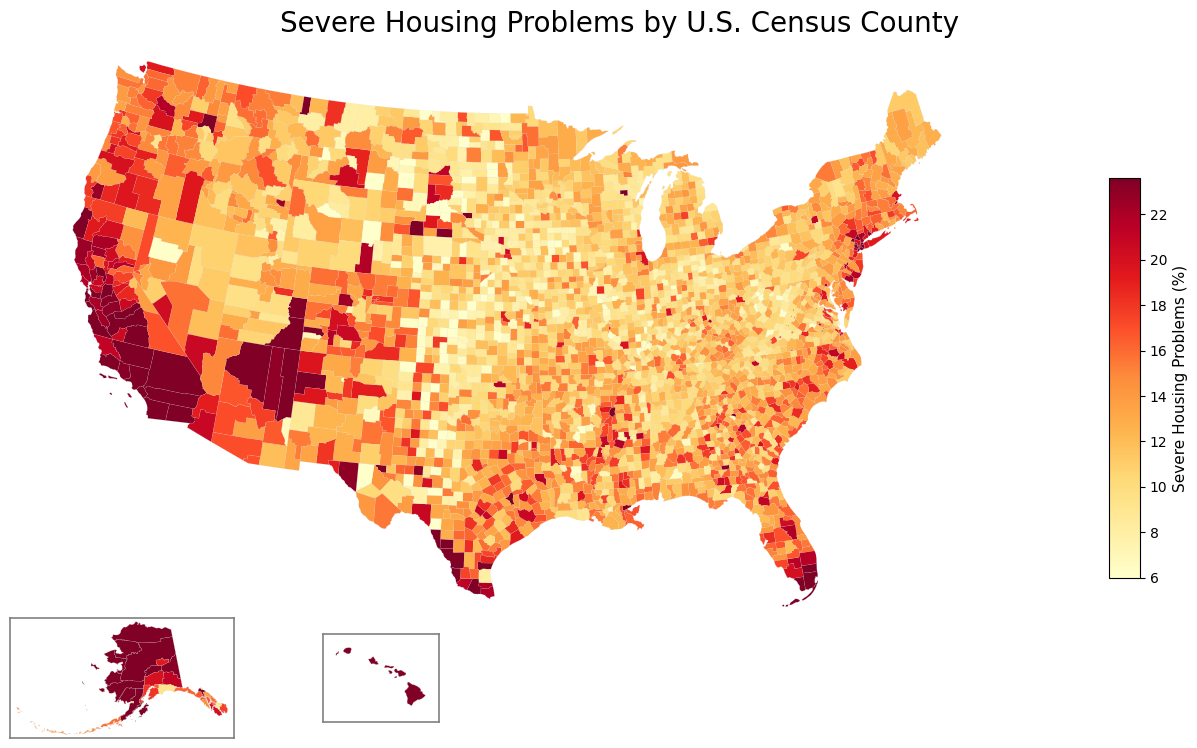

In [1]:
# Open In Colab

# Run once
# ! pip install geopandas pandas numpy matplotlib openpyxl

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file = "/content/2025 County Health Rankings Data - v4.xlsx"

# Load County Health Rankings data
excel_data = pd.read_excel(
    file,
    sheet_name="Select Measure Data",
    header=1
)

# Severe housing problems data
shp = excel_data[[
    "FIPS",
    "State",
    "County",
    "% Severe Housing Problems"
]].copy()

# Keep only county rows, while not removing missing severe housing values
shp = shp[shp["County"].notna()].copy()

# Clean FIPS and severe housing column
shp["FIPS"] = (
    shp["FIPS"]
    .astype(int)
    .astype(str)
    .str.zfill(5)
)

shp["% Severe Housing Problems"] = pd.to_numeric(
    shp["% Severe Housing Problems"],
    errors="coerce"
)

# Load county shapefile from U.S. Census Bureau
counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_20m.zip"
)

# Make sure coordinates are latitude/longitude
counties = counties.to_crs(epsg=4326)

# Merge severe housing problems data with county map
merged = counties.merge(
    shp,
    left_on="GEOID",
    right_on="FIPS",
    how="left"
)

# Remove U.S. territories only
territory_codes = ["60", "66", "69", "72", "78"]
merged = merged[~merged["STATEFP"].isin(territory_codes)].copy()

# Split into maps
lower48 = merged[~merged["STATEFP"].isin(["02", "15"])].copy()
alaska = merged[merged["STATEFP"] == "02"].copy()
hawaii = merged[merged["STATEFP"] == "15"].copy()

# Color scale
housing_values = merged["% Severe Housing Problems"].dropna()
vmin = housing_values.quantile(0.02)
vmax = housing_values.quantile(0.98)

# Projections
lower48_proj = lower48.to_crs(epsg=5070)
alaska_proj = alaska.to_crs(epsg=3338)
hawaii_proj = hawaii.to_crs(epsg=4326)

# Figure layout
fig = plt.figure(figsize=(14, 8), facecolor="white")

# Main Lower 48 map
ax_main = fig.add_axes([0.02, 0.18, 0.80, 0.75])

lower48_proj.plot(
    column="% Severe Housing Problems",
    cmap="YlOrRd",
    legend=False,
    edgecolor="lightgray",
    linewidth=0.08,
    vmin=vmin,
    vmax=vmax,
    ax=ax_main,
    missing_kwds={
        "color": "#eeeeee",
        "edgecolor": "lightgray",
        "linewidth": 0.08
    }
)

ax_main.axis("off")

# Alaska inset box
ax_ak = fig.add_axes([0.05, 0.05, 0.19, 0.15])
ax_ak.set_facecolor("white")

alaska_proj.plot(
    column="% Severe Housing Problems",
    cmap="YlOrRd",
    legend=False,
    edgecolor="lightgray",
    linewidth=0.12,
    vmin=vmin,
    vmax=vmax,
    ax=ax_ak,
    missing_kwds={
        "color": "#eeeeee",
        "edgecolor": "lightgray",
        "linewidth": 0.12
    }
)

minx, miny, maxx, maxy = alaska_proj.total_bounds
x_buffer = (maxx - minx) * 0.03
y_buffer = (maxy - miny) * 0.03

ax_ak.set_xlim(minx - x_buffer, maxx + x_buffer)
ax_ak.set_ylim(miny - y_buffer, maxy + y_buffer)

for spine in ax_ak.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_edgecolor("gray")

ax_ak.set_xticks([])
ax_ak.set_yticks([])

# Hawaii inset box
ax_hi = fig.add_axes([0.28, 0.07, 0.10, 0.11])
ax_hi.set_facecolor("white")

hawaii_proj.plot(
    column="% Severe Housing Problems",
    cmap="YlOrRd",
    legend=False,
    edgecolor="lightgray",
    linewidth=0.12,
    vmin=vmin,
    vmax=vmax,
    ax=ax_hi,
    missing_kwds={
        "color": "#eeeeee",
        "edgecolor": "lightgray",
        "linewidth": 0.12
    }
)

ax_hi.set_xlim(-161, -154)
ax_hi.set_ylim(18, 23)

for spine in ax_hi.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_edgecolor("gray")

ax_hi.set_xticks([])
ax_hi.set_yticks([])

# Colorbar
ax_cbar = fig.add_axes([0.85, 0.25, 0.022, 0.50])

sm = plt.cm.ScalarMappable(
    cmap="YlOrRd",
    norm=plt.Normalize(vmin=vmin, vmax=vmax)
)
sm._A = []

cbar = fig.colorbar(sm, cax=ax_cbar)
cbar.set_label("Severe Housing Problems (%)", fontsize=11)

# Title
fig.suptitle(
    "Severe Housing Problems by U.S. Census County",
    fontsize=20,
    y=0.96
)

plt.show()